In [2]:
import os
import copy
import time
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, WeightedRandomSampler
from torchvision import datasets, transforms, models

from torch.utils.data import DataLoader

from sklearn.metrics import classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [3]:

# ==========================================================
# Multiclass Crime Detection using EfficientNetB0
# Cell 1 - Mount Google Drive
# ==========================================================

from google.colab import drive
import os

drive.mount("/content/drive", force_remount=True)

print("Drive mounted successfully.")

DATASET_PATH = "/content/drive/MyDrive/OUR_DATASET/Combined_Dataset_Augmented"

if os.path.exists(DATASET_PATH):
    print("\nDataset found.")
    print(DATASET_PATH)
else:
    print("\nDataset NOT found.")

Mounted at /content/drive
Drive mounted successfully.

Dataset found.
/content/drive/MyDrive/OUR_DATASET/Combined_Dataset_Augmented


In [4]:
# ==========================================================
# Multiclass Crime Detection using DenseNet121
# Cell 3 - Configuration
# ==========================================================

MODEL_NAME = "DenseNet121"

DATASET_PATH = "/content/drive/MyDrive/OUR_DATASET/Combined_Dataset_Augmented"

TRAIN_DIR = os.path.join(DATASET_PATH, "Train")
VAL_DIR = os.path.join(DATASET_PATH, "Validation")
TEST_DIR = os.path.join(DATASET_PATH, "Test"

)

NUM_CLASSES = 6

CLASS_NAMES = sorted(os.listdir(TRAIN_DIR))

print("Classes Found:")
print(CLASS_NAMES)

BASE_PATH = "/content/drive/MyDrive/OUR_DATASET"

REPORT_PATH = os.path.join(BASE_PATH, MODEL_NAME)

os.makedirs(REPORT_PATH, exist_ok=True)

MODEL_PATH = os.path.join(
    REPORT_PATH,
    f"crime_detector_{MODEL_NAME}.pth"
)

print("\nConfiguration Loaded Successfully")

Classes Found:
['Abuse', 'Burglary', 'Fighting', 'Normal', 'RoadAccident', 'Snatching']

Configuration Loaded Successfully


In [5]:
# 3. Image Treansformations

IMAGE_SIZE = 224
BATCH_SIZE = 32

train_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.RandomResizedCrop(224, scale=(0.8,1.0)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],
                         [0.229,0.224,0.225])
])

test_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],
                         [0.229,0.224,0.225])
])

In [14]:
# 6. Compute Class Weights

import numpy as np

# Labels for every training image
train_targets = train_dataset.targets

# Count samples per class
class_counts = np.bincount(train_targets)

print("Samples per class:")
for cls, count in zip(CLASS_NAMES, class_counts):
    print(f"{cls}: {count}")

# Weight of each class = inverse of its frequency
class_weights = 1.0 / class_counts

# Assign a weight to every sample
sample_weights = [class_weights[label] for label in train_targets]

sample_weights = torch.DoubleTensor(sample_weights)

Samples per class:
Abuse: 2000
Burglary: 2000
Fighting: 2000
Normal: 2000
RoadAccident: 2000
Snatching: 3708


In [15]:
# Weighted Random Sampler

sampler = WeightedRandomSampler(
    weights=sample_weights,
    num_samples=len(sample_weights),
    replacement=True
)

In [16]:
# 4. Load Dataset

train_dataset = datasets.ImageFolder(TRAIN_DIR, transform=train_transform)
val_dataset = datasets.ImageFolder(VAL_DIR, transform=test_transform)
test_dataset = datasets.ImageFolder(TEST_DIR, transform=test_transform)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    sampler=sampler,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(val_dataset,
                        batch_size=BATCH_SIZE,
                        shuffle=False)

test_loader = DataLoader(test_dataset,
                         batch_size=BATCH_SIZE,
                         shuffle=False)

In [17]:
# 5. Class Names

CLASS_NAMES = train_dataset.classes

print(CLASS_NAMES)

['Abuse', 'Burglary', 'Fighting', 'Normal', 'RoadAccident', 'Snatching']


In [18]:
# 7. Load DenseNet121

model = models.densenet121(weights=models.DenseNet121_Weights.DEFAULT)

Downloading: "https://download.pytorch.org/models/densenet121-a639ec97.pth" to /root/.cache/torch/hub/checkpoints/densenet121-a639ec97.pth


100%|██████████| 30.8M/30.8M [00:00<00:00, 185MB/s]


In [19]:
# Freeze base layers

for param in model.features.parameters():
    param.requires_grad = False

In [20]:
# Replace Classifier

num_features = model.classifier.in_features

model.classifier = nn.Sequential(
    nn.Dropout(0.3),
    nn.Linear(num_features, len(CLASS_NAMES))
)

model = model.to(device)

In [21]:
# 8. Loss and Optimizer

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=0.0001
)

In [23]:
# 9. Training Loop

EPOCHS = 30

train_acc_history = []
val_acc_history = []

train_loss_history = []
val_loss_history = []

best_acc = 0
patience = 5
counter = 0

best_model = copy.deepcopy(model.state_dict())

In [24]:
for epoch in range(EPOCHS):

    print(f"Epoch {epoch+1}/{EPOCHS}")

    ##################
    # TRAIN
    ##################

    model.train()

    running_loss = 0
    running_corrects = 0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        _, preds = torch.max(outputs,1)

        running_loss += loss.item()*images.size(0)
        running_corrects += torch.sum(preds==labels)

    epoch_loss = running_loss/len(train_dataset)
    epoch_acc = running_corrects.double()/len(train_dataset)

    train_loss_history.append(epoch_loss)
    train_acc_history.append(epoch_acc.cpu())

    ##################
    # VALIDATION
    ##################

    model.eval()

    running_loss = 0
    running_corrects = 0

    with torch.no_grad():

        for images, labels in val_loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            loss = criterion(outputs,labels)

            _, preds = torch.max(outputs,1)

            running_loss += loss.item()*images.size(0)
            running_corrects += torch.sum(preds==labels)

    val_loss = running_loss/len(val_dataset)
    val_acc = running_corrects.double()/len(val_dataset)

    val_loss_history.append(val_loss)
    val_acc_history.append(val_acc.cpu())

    print(f"Train Acc : {epoch_acc:.4f}")
    print(f"Val Acc   : {val_acc:.4f}")

    if val_acc > best_acc:

        best_acc = val_acc

        best_model = copy.deepcopy(model.state_dict())

        counter = 0

    else:

        counter += 1

    if counter >= patience:

        print("Early stopping")
        break

Epoch 1/30
Train Acc : 0.4846
Val Acc   : 0.4596
Epoch 2/30
Train Acc : 0.7455
Val Acc   : 0.5617
Epoch 3/30
Train Acc : 0.8038
Val Acc   : 0.5907
Epoch 4/30
Train Acc : 0.8370
Val Acc   : 0.6108
Epoch 5/30
Train Acc : 0.8521
Val Acc   : 0.6092
Epoch 6/30
Train Acc : 0.8626
Val Acc   : 0.6108
Epoch 7/30
Train Acc : 0.8725
Val Acc   : 0.5903
Epoch 8/30
Train Acc : 0.8867
Val Acc   : 0.6080
Epoch 9/30
Train Acc : 0.8839
Val Acc   : 0.5871
Early stopping


In [25]:
# 10. Save Best Model
model.load_state_dict(best_model)

torch.save(model.state_dict(),
            MODEL_PATH)

print("Model Saved")

Model Saved


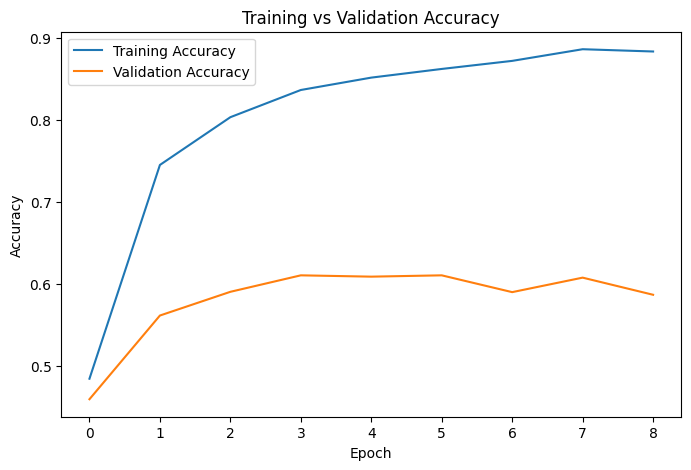

Accuracy plot saved to:
/content/drive/MyDrive/OUR_DATASET/DenseNet121/accuracy_plot.png


In [26]:
# 11. Accuracy Plot

plt.figure(figsize=(8,5))

plt.plot(train_acc_history, label="Training Accuracy")
plt.plot(val_acc_history, label="Validation Accuracy")

plt.title("Training vs Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

accuracy_plot_path = os.path.join(REPORT_PATH, "accuracy_plot.png")

plt.savefig(
    accuracy_plot_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

print(f"Accuracy plot saved to:\n{accuracy_plot_path}")

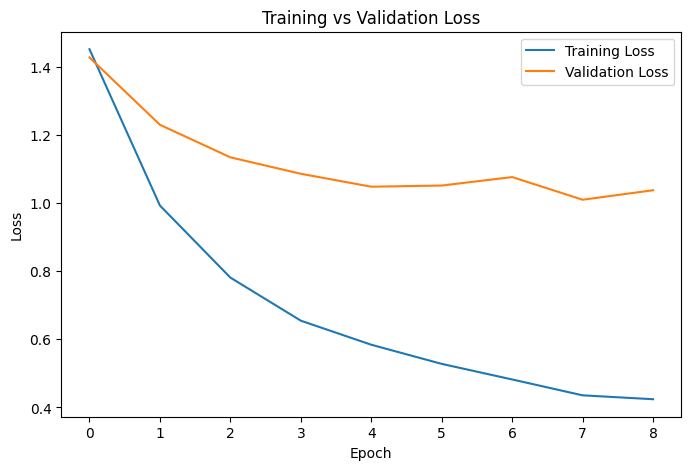

Loss plot saved to:
/content/drive/MyDrive/OUR_DATASET/DenseNet121/loss_plot.png


In [27]:
# 12. Loss Plot

plt.figure(figsize=(8,5))

plt.plot(train_loss_history, label="Training Loss")
plt.plot(val_loss_history, label="Validation Loss")

plt.title("Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

loss_plot_path = os.path.join(REPORT_PATH, "loss_plot.png")

plt.savefig(
    loss_plot_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

print(f"Loss plot saved to:\n{loss_plot_path}")

In [28]:
# ==========================================================
# 13. Test Evaluation
# ==========================================================

model.eval()

test_loss = 0.0
correct = 0

predictions = []
actual = []

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        loss = criterion(outputs, labels)
        test_loss += loss.item() * images.size(0)

        _, preds = torch.max(outputs, 1)

        correct += torch.sum(preds == labels).item()

        predictions.extend(preds.cpu().numpy())
        actual.extend(labels.cpu().numpy())

# Calculate metrics
test_loss = test_loss / len(test_dataset)
test_accuracy = correct / len(test_dataset)

print(f"Test Loss     : {test_loss:.4f}")
print(f"Test Accuracy : {test_accuracy:.4f}")

Test Loss     : 1.1386
Test Accuracy : 0.5295


In [29]:
import pandas as pd

evaluation_df = pd.DataFrame({
    "Metric": ["Test Loss", "Test Accuracy"],
    "Value": [test_loss, test_accuracy]
})

evaluation_df.to_csv(
    os.path.join(REPORT_PATH, "test_evaluation.csv"),
    index=False
)

print("Test evaluation saved.")

Test evaluation saved.


In [30]:
# 14. Classification Report
import pandas as pd
from sklearn.metrics import classification_report

report = classification_report(
    actual,
    predictions,
    target_names=CLASS_NAMES,
    output_dict=True
)

report_df = pd.DataFrame(report).transpose()

report_path = os.path.join(
    REPORT_PATH,
    "classification_report.csv"
)

report_df.to_csv(report_path, index=True)

print(f"Classification report saved to:\n{report_path}")

Classification report saved to:
/content/drive/MyDrive/OUR_DATASET/DenseNet121/classification_report.csv


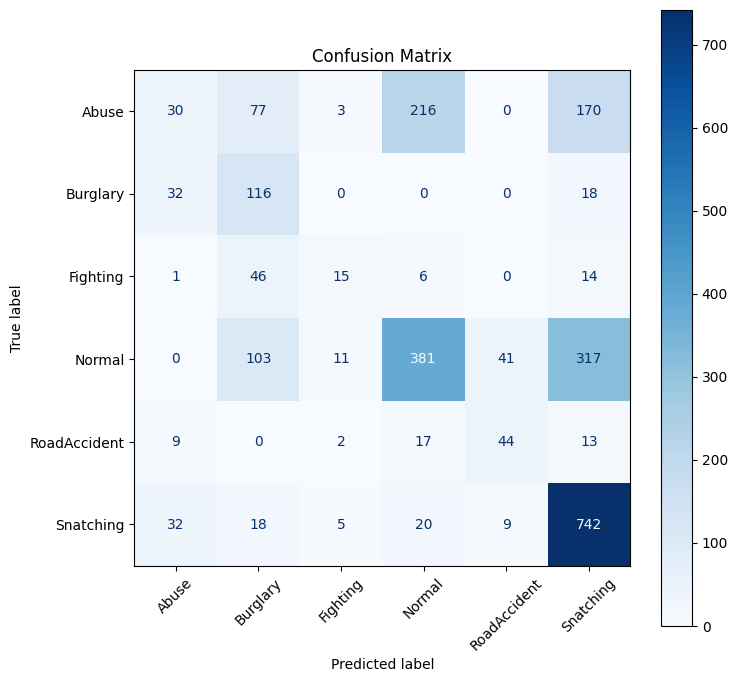

Confusion matrix saved to:
/content/drive/MyDrive/OUR_DATASET/DenseNet121/confusion_matrix.png


In [31]:
# 15. Confusion matrix
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(actual, predictions)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=CLASS_NAMES
)

fig, ax = plt.subplots(figsize=(8,8))
disp.plot(ax=ax, cmap="Blues", xticks_rotation=45)

plt.title("Confusion Matrix")

cm_path = os.path.join(
    REPORT_PATH,
    "confusion_matrix.png"
)

plt.savefig(
    cm_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

print(f"Confusion matrix saved to:\n{cm_path}")

In [32]:
# Saving Predicitons.csv

pred_df = pd.DataFrame({
    "Actual": [CLASS_NAMES[i] for i in actual],
    "Predicted": [CLASS_NAMES[i] for i in predictions]
})

pred_df["Correct"] = pred_df["Actual"] == pred_df["Predicted"]

pred_df.to_csv(
    os.path.join(REPORT_PATH, "predictions.csv"),
    index=False
)

print("Predictions saved.")

Predictions saved.
